# **Gold Price Time Series Analyze**
#### **Daily gold prices** from January 1, 2014 to January 2, 2026

### Import Necessary Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from datetime import timedelta
from sklearn.metrics import confusion_matrix,mean_squared_error
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras import models, layers

from statsmodels.tsa.arima.model import ARIMA

### Read Data, Explore data

In [2]:
data=pd.read_csv('Gold Price.csv')

In [3]:
data.head()

,Date,Price,Open,High,Low,Volume,Chg%
0,1/1/2014,29542,29435,29598,29340,2930,0.25
1,1/2/2014,29975,29678,30050,29678,3140,1.47
2,1/3/2014,29727,30031,30125,29539,3050,-0.83
3,1/4/2014,29279,29279,29279,29279,0,-1.51
4,1/6/2014,29119,29300,29395,29051,24380,-0.55


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3104 entries, 0 to 3103
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3104 non-null   str    
 1   Price   3104 non-null   int64  
 2   Open    3104 non-null   int64  
 3   High    3104 non-null   int64  
 4   Low     3104 non-null   int64  
 5   Volume  3104 non-null   int64  
 6   Chg%    3104 non-null   float64
dtypes: float64(1), int64(5), str(1)
memory usage: 169.9 KB


In [5]:
data.describe()

,Price,Open,High,Low,Volume,Chg%
count,3104.000000,3104.000000,3104.000000,3104.000000,3104.000000,3104.000000
mean,46263.721972,46250.184278,46515.665271,45997.234214,14855.159472,0.052957
std,22230.385519,22191.261855,22364.944669,22053.596236,14197.123722,0.854364
min,24545.000000,24583.000000,24635.000000,24470.000000,0.000000,-5.980000
25%,29358.750000,29331.500000,29462.750000,29214.000000,6780.000000,-0.370000
50%,38832.500000,38902.500000,39083.000000,38626.500000,11520.000000,0.060000
75%,54970.250000,54900.000000,55211.250000,54730.500000,18602.500000,0.480000
max,137789.000000,137628.000000,138300.000000,136300.000000,149474.000000,5.300000


In [6]:
# Convert the 'Date' column to datetime format
data['Date']=pd.to_datetime(data['Date'])

In [7]:
data['Month']=data['Date'].dt.month_name()
data['Year']=data['Date'].dt.year

In [8]:
#set the index by date
data=data.set_index('Date')

In [9]:
data.head()

,Price,Open,High,Low,Volume,Chg%,Month,Year
Date,,,,,,,,
2014-01-01,29542,29435,29598,29340,2930,0.25,January,2014
2014-01-02,29975,29678,30050,29678,3140,1.47,January,2014
2014-01-03,29727,30031,30125,29539,3050,-0.83,January,2014
2014-01-04,29279,29279,29279,29279,0,-1.51,January,2014
2014-01-06,29119,29300,29395,29051,24380,-0.55,January,2014


In [10]:
data['Year'].unique()

array([2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024,
       2025, 2026], dtype=int32)

In [11]:
data['Month'].unique()

<StringArray>
[  'January',  'February',     'March',     'April',       'May',      'June',
      'July',    'August', 'September',   'October',  'November',  'December']
Length: 12, dtype: str

### EDA

In [12]:
def plot_feature(col,color):
   plt.plot(data[col],color)
   plt.title(f'Trend of {col}')
   plt.ylabel(f'{col}')

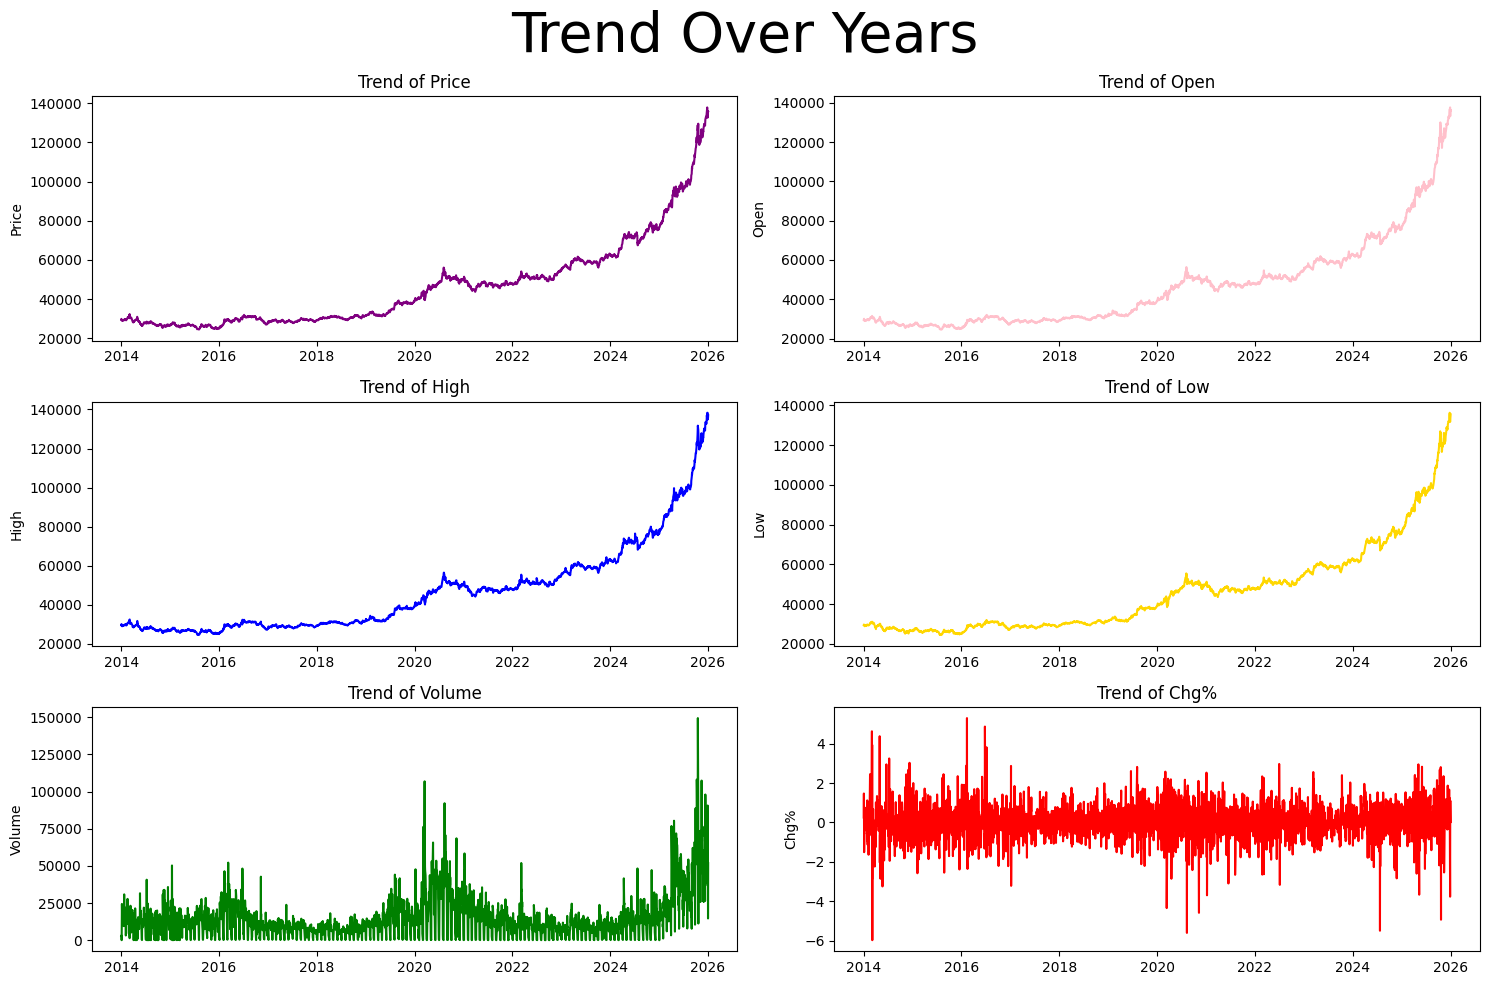

In [13]:
plt.figure(figsize=(15,10))
colors=['purple','pink','blue','gold','green','red']
plt.suptitle('Trend Over Years',fontsize=40)
for i,col in enumerate(data.columns[:-2]):
    plt.subplot(3,2,i+1)
    plot_feature(col,colors[i])
plt.tight_layout()
plt.savefig("Figures/Trend Over Years.png")
plt.show()

In [14]:
#total price over months
months = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
month_grouped=data.groupby('Month').sum()
month_grouped=month_grouped.sort_values(by='Price')
month_grouped=month_grouped.reindex(months)
month_grouped

,Price,Open,High,Low,Volume,Chg%,Year
Month,,,,,,,
January,11349070,11341792,11398333,11295207,3446633,38.64,533149
February,10652553,10654794,10713876,10591438,3109291,11.06,496795
March,11466112,11461936,11539432,11386938,4217844,6.28,531122
April,11180768,11170459,11246753,11103430,3603605,38.91,496785
May,12175460,12174600,12244035,12105720,4326861,-5.61,537193
June,11751735,11754937,11814017,11690870,3649135,7.55,519005
July,12445472,12447146,12511454,12382435,4054505,10.76,545243
August,11953597,11946187,12014771,11883535,3812367,20.87,519006
September,12379776,12376573,12440236,12313638,3999501,0.42,525057


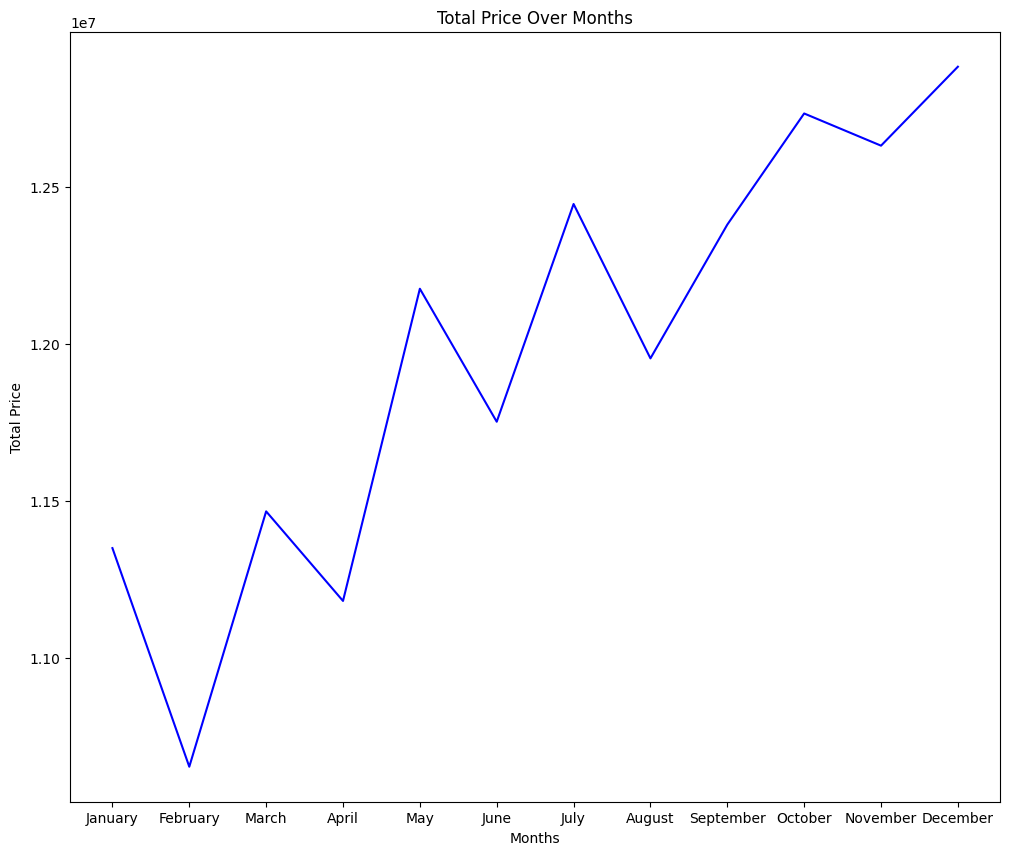

In [15]:
plt.figure(figsize=(12,10))
plt.title('Total Price Over Months')
plt.xlabel('Months')
plt.ylabel('Total Price')
plt.plot(month_grouped.index,month_grouped['Price'],colors[2])
plt.savefig("Figures/Total Price Over Months.png")
plt.show()

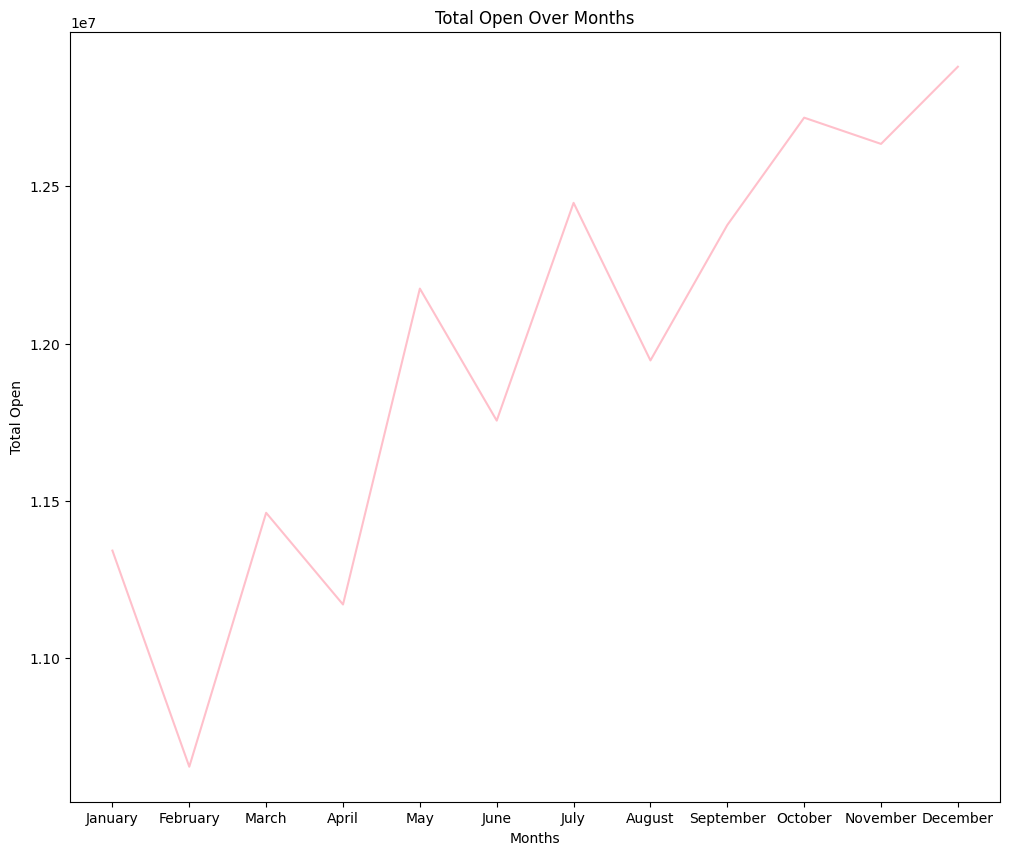

In [16]:
plt.figure(figsize=(12,10))
plt.title('Total Open Over Months')
plt.xlabel('Months')
plt.ylabel('Total Open')
plt.plot(month_grouped.index,month_grouped['Open'],colors[1])
plt.savefig("Figures/Total Open Over Months.png")
plt.show()


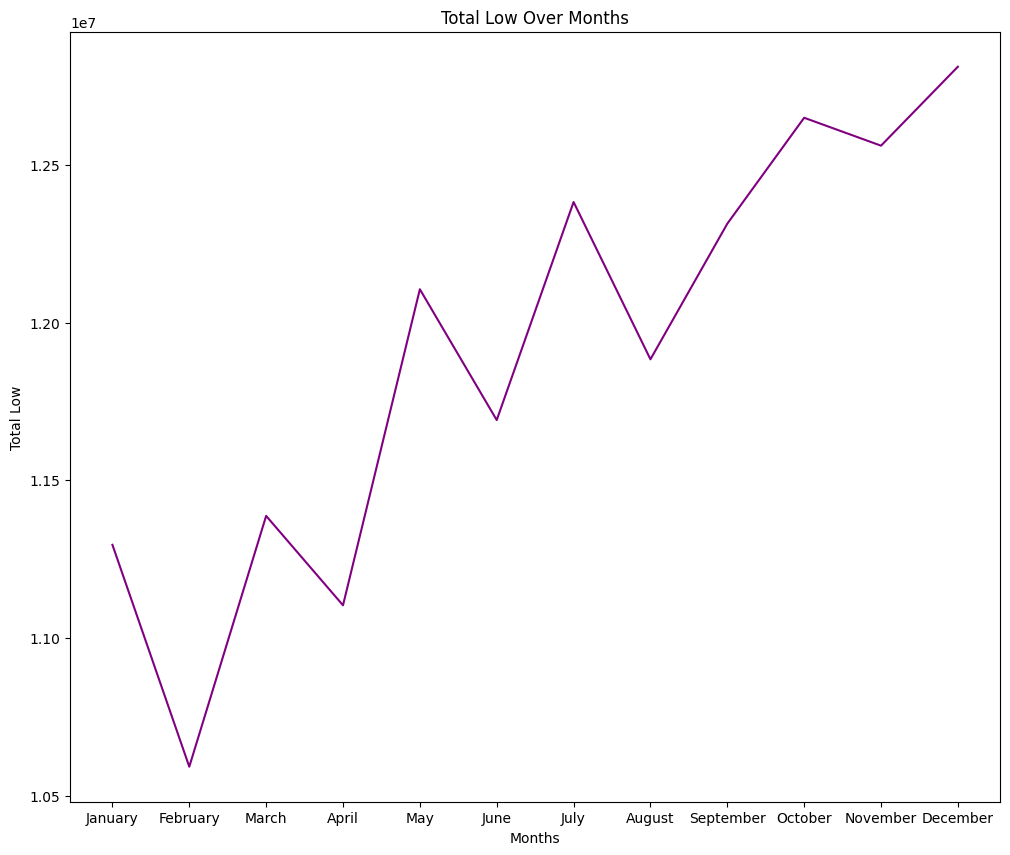

In [17]:
plt.figure(figsize=(12,10))
plt.title('Total Low Over Months')
plt.xlabel('Months')
plt.ylabel('Total Low')
plt.plot(month_grouped.index,month_grouped['Low'],colors[0])
plt.savefig("Figures/Total Low Over Months.png")
plt.show()

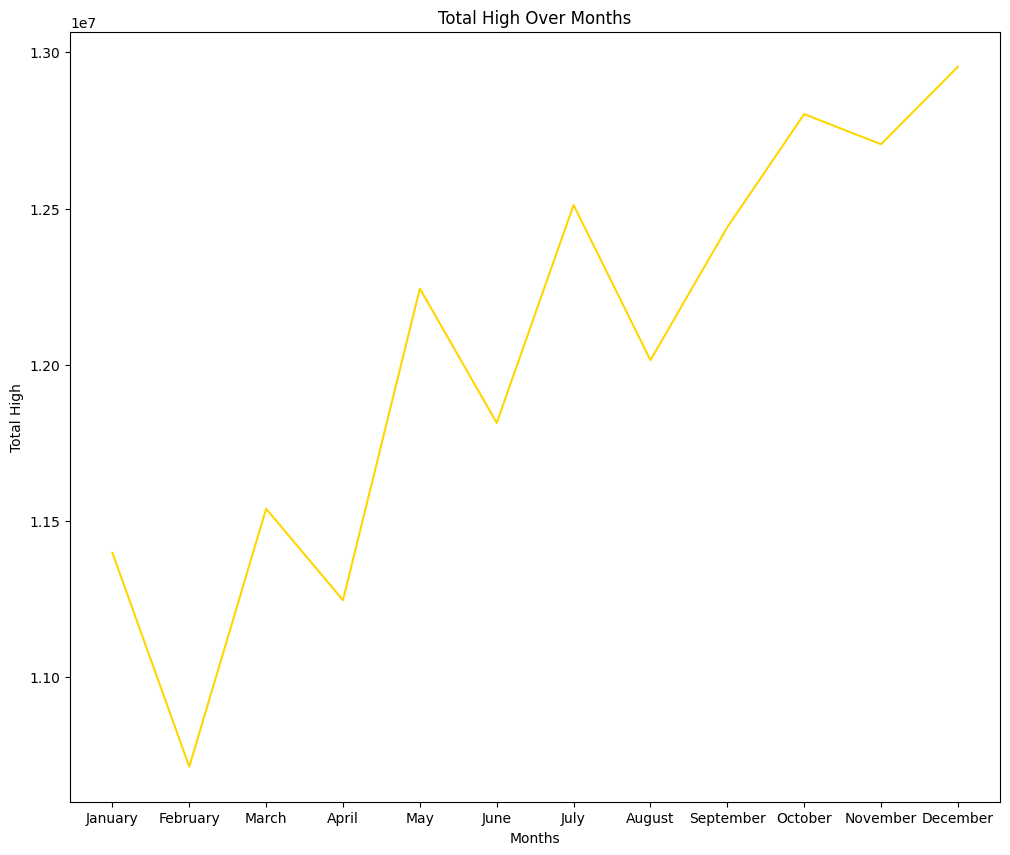

In [18]:
plt.figure(figsize=(12,10))
plt.title('Total High Over Months')
plt.plot(month_grouped.index,month_grouped['High'],colors[3])
plt.xlabel('Months')
plt.ylabel('Total High')
plt.savefig("Figures/Total High Over Months.png")
plt.show()


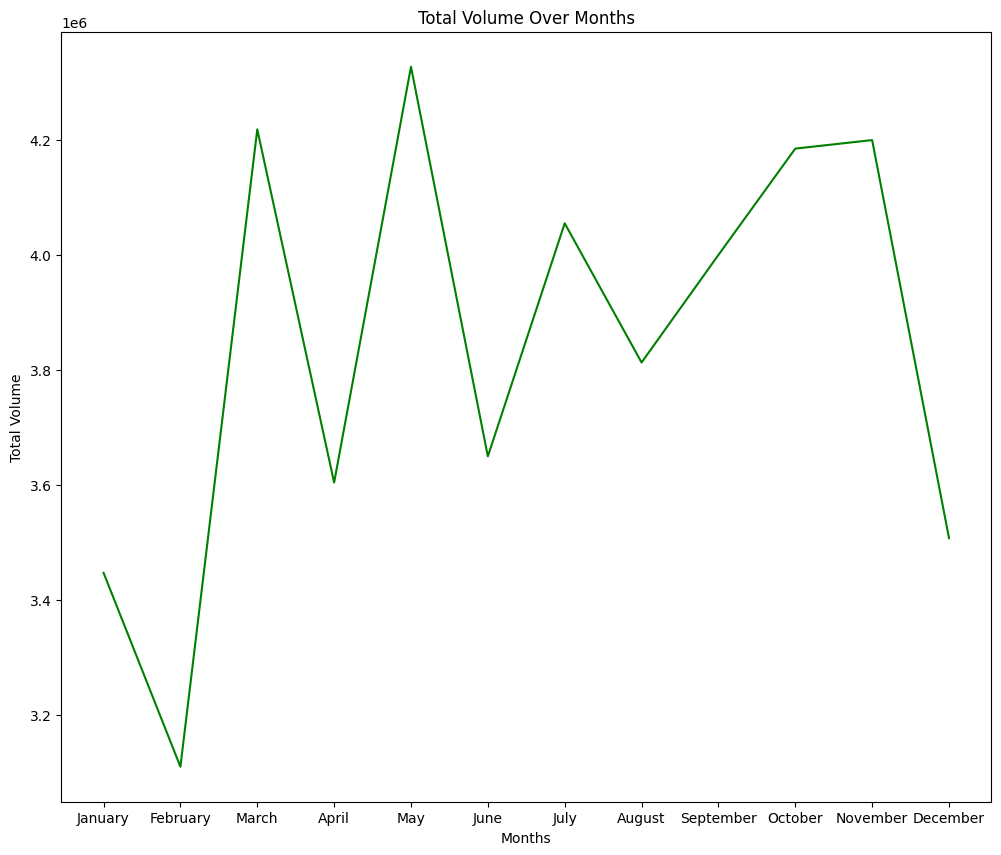

In [19]:
plt.figure(figsize=(12,10))
plt.title('Total Volume Over Months')
plt.plot(month_grouped.index,month_grouped['Volume'],colors[4])
plt.xlabel('Months')
plt.ylabel('Total Volume')
plt.savefig("Figures/Total Volume Over Months.png")
plt.show()

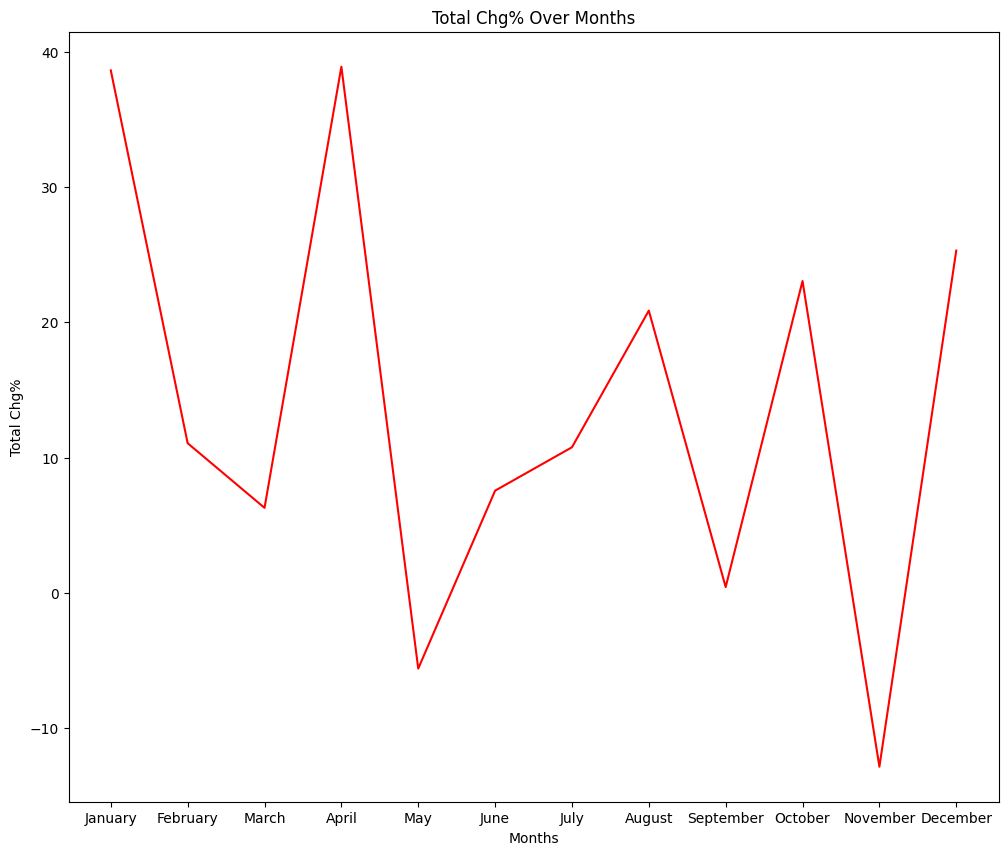

In [20]:
plt.figure(figsize=(12,10))
plt.title('Total Chg% Over Months')
plt.plot(month_grouped.index,month_grouped['Chg%'],colors[5])
plt.xlabel('Months')
plt.ylabel('Total Chg%')
plt.savefig("Figures/Total Chg% Over Months.png")
plt.show()


In [21]:
years=data['Year'].unique()
grouped_year=data.groupby('Year',)[data.columns[:-2]].mean()
grouped_year=grouped_year.sort_values(by='Price')
grouped_year=grouped_year.reindex(years)
grouped_year


,Price,Open,High,Low,Volume,Chg%
Year,,,,,,
2014,28101.361940,28091.723881,28273.578358,27927.854478,12407.313433,-0.032724
2015,26304.965649,26321.713740,26461.156489,26167.580153,12675.835878,-0.021069
2016,29427.718147,29433.193050,29611.220077,29255.996139,14576.096525,0.045097
2017,28949.235294,28941.313725,29060.498039,28827.043137,7799.596078,0.025255
2018,30635.257812,30631.300781,30757.191406,30514.167969,7081.398438,0.028945
2019,34887.945525,34888.221790,35070.163424,34707.276265,13946.809339,0.085992
2020,47267.914729,47247.779070,47604.972868,46854.120155,26857.860465,0.103488
2021,47344.729730,47377.814672,47603.216216,47115.200772,14459.922780,-0.013475
2022,50994.568093,51001.322957,51267.871595,50745.276265,9279.525292,0.054786


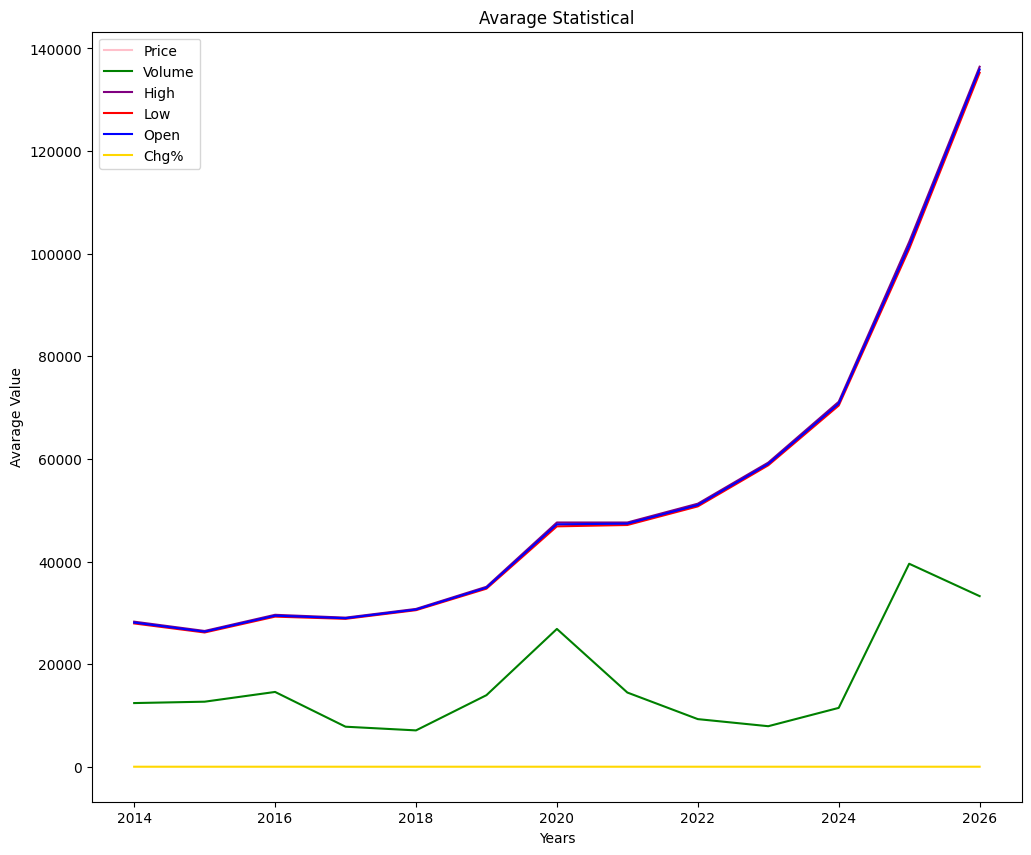

In [22]:
plt.figure(figsize=(12,10))
plt.plot(grouped_year['Price'],colors[1])
plt.plot(grouped_year['Volume'],colors[4])
plt.plot(grouped_year['High'],colors[0])
plt.plot(grouped_year['Low'],colors[5])
plt.plot(grouped_year['Open'],colors[2])
plt.plot(grouped_year['Chg%'],colors[3])
plt.legend(['Price','Volume','High','Low','Open','Chg%'])
plt.title(f'Avarage Statistical')
plt.xlabel('Years')
plt.ylabel('Avarage Value')
plt.savefig("Figures/Average Statistical Over Years.png")
plt.show()

## Model build Preparation 

In [23]:
# Target Column is Price
training,test=[],[]
no_cols=1
time_steps=60
features=data['Price']
features=pd.DataFrame(features)
train_size=int(len(features) * .80)
test_size=len(features) - train_size
print(f'Train size: {train_size} \nTest size: {test_size}')


Train size: 2483 
Test size: 621


### Normalize the data

In [24]:
scaler = MinMaxScaler(feature_range= (0, 1))
scaled_data = scaler.fit_transform(np.array(features).reshape(-1, 1))

In [25]:
training=scaled_data[:train_size,:]
test=scaled_data[train_size-time_steps:,:]
training.shape,test.shape

((2483, 1), (681, 1))

In [26]:
x_train = []
y_train = []

for i in range(60, len(training)):
    x_train.append(training[i-60:i, 0])
    y_train.append(training[i, 0])
x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))


In [27]:
x_train.shape,y_train.shape

((2423, 60, 1), (2423,))

### **1. LSTM Model**

In [28]:
model=models.Sequential([
    layers.LSTM(60, return_sequences= True, input_shape= (x_train.shape[1], 1)),
    layers.LSTM(64, return_sequences= True),
    layers.LSTM(64, return_sequences= False),
    layers.Dense(32,activation='relu'),
    layers.Dense(16,activation='relu'),
    layers.Dense(1,activation='linear')
])

model.compile(optimizer='adam',loss='mse',metrics=['mean_absolute_error'])

model.build()

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [29]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 60)         │        14,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 64)         │        32,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,529 (322.38 KB)

 Trainable params: 82,529 (322.38 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
history=model.fit(x_train,y_train,epochs=100,batch_size=32,verbose=1,
                  callbacks=[tf.keras.callbacks.EarlyStopping(monitor= 'loss', patience= 10 , restore_best_weights= True)])

Epoch 1/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 0.0016 - mean_absolute_error: 0.0221
Epoch 2/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 9.3307e-05 - mean_absolute_error: 0.0073
Epoch 3/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 8.8223e-05 - mean_absolute_error: 0.0071
Epoch 4/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 8.4903e-05 - mean_absolute_error: 0.0069
Epoch 5/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 8.0514e-05 - mean_absolute_error: 0.0067
Epoch 6/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 7.8095e-05 - mean_absolute_error: 0.0067
Epoch 7/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 7.3374e-05 - mean_absolute_error: 0.0064
Epoch 8/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 8.0255e-05 - mean_absolute_error: 0.0067
Epoch 9/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 7.3700e-05 - mean_absolute_error: 0.0064
Epoch 10/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 6.2883e-05 - mean_absolute_error: 

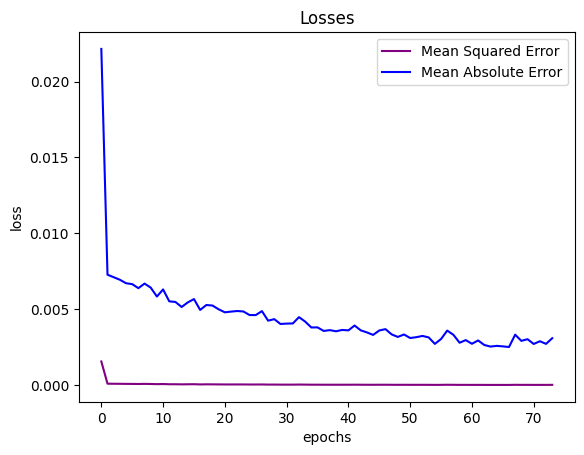

In [31]:
plt.plot(history.history["loss"],colors[0])
plt.plot(history.history["mean_absolute_error"],colors[2])
plt.legend(['Mean Squared Error','Mean Absolute Error'])
plt.title("Losses")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.savefig("Figures/Losses.png")
plt.show()

In [32]:
x_test = []
y_test = []

for i in range(60, len(test)):
    x_test.append(test[i-60:i, 0])
    y_test.append(test[i, 0])
x_test, y_test = np.array(x_test), np.array(y_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

In [33]:
x_test.shape,y_test.shape

((621, 60, 1), (621,))

In [34]:
x_test[:10]

array([[[0.32052912],
        [0.32180071],
        [0.31555756],
        [0.31475398],
        [0.31094804],
        [0.31652008],
        [0.31547808],
        [0.31502773],
        [0.31236092],
        [0.30860796],
        [0.30805164],
        [0.30741585],
        [0.31171629],
        [0.3153103 ],
        [0.31337643],
        [0.31004733],
        [0.31136307],
        [0.31221963],
        [0.30876691],
        [0.3113984 ],
        [0.31111582],
        [0.30950867],
        [0.3062149 ],
        [0.30645332],
        [0.30645332],
        [0.30645332],
        [0.30463424],
        [0.30179082],
        [0.30098725],
        [0.29669563],
        [0.29708417],
        [0.29768465],
        [0.2955565 ],
        [0.29362262],
        [0.29169757],
        [0.29560065],
        [0.29647487],
        [0.29713716],
        [0.29814383],
        [0.29882378],
        [0.30202042],
        [0.3010314 ],
        [0.30193211],
        [0.30525238],
        [0.30588817],
        [0

In [35]:
#inverse y_test scaling
predictions = model.predict(x_test)

#inverse predictions scaling
predictions = scaler.inverse_transform(predictions)
predictions.shape

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


(621, 1)

In [36]:
y_test = scaler.inverse_transform([y_test])

In [37]:
RMSE = np.sqrt(np.mean( y_test - predictions )**2).round(2)
RMSE

np.float64(43.55)

In [38]:
train = features.iloc[:train_size , 0:1]
test = features.iloc[train_size: , 0:1]
test['Predictions'] =predictions
test

,Price,Predictions
Date,,
2023-08-04,59124,59039.621094
2023-08-07,59201,59085.359375
2023-08-08,58997,59193.417969
2023-08-09,58719,59110.074219
2023-08-10,58605,58836.234375
...,...,...
2025-12-29,132595,138130.765625
2025-12-30,133974,131669.000000
2025-12-31,135454,131710.937500


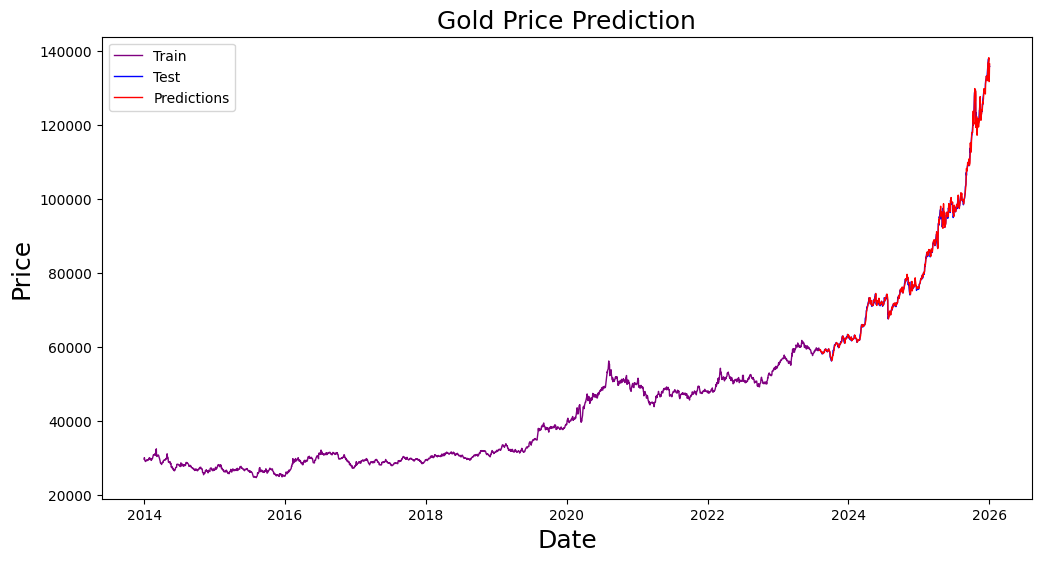

In [39]:
plt.figure(figsize= (12, 6))
plt.title('Gold Price Prediction', fontsize= 18)
plt.xlabel('Date', fontsize= 18)
plt.ylabel('Price', fontsize= 18)
plt.plot(train['Price'],colors[0] ,linewidth= 1)
plt.plot(test['Price'],colors[2] ,linewidth= 1)
plt.plot(test["Predictions"],colors[5] ,linewidth= 1)
plt.legend(['Train', 'Test', 'Predictions'])
plt.savefig("Figures/Gold Price Prediction.png")
plt.show()

### Forecasting the next 30 days

In [40]:
def insert_end(Xin, new_input):
    timestep = 60
    for i in range(timestep - 1):
        Xin[:, i, :] = Xin[:, i+1, :]
    Xin[:, timestep - 1, :] = new_input
    return Xin

In [41]:
future = 90
forcast = []
Xin = x_test[-1 :, :, :]
time = []
for i in range(0, future):
    out = model.predict(Xin, batch_size=5)
    forcast.append(out[0, 0])
    print(forcast)
    Xin = insert_end(Xin, out[0, 0])
    time.append(pd.to_datetime(data.index[-1]) + timedelta(days=i))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
[np.float32(0.987946)]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
[np.float32(0.987946), np.float32(0.9903289)]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
[np.float32(0.987946), np.float32(0.9903289), np.float32(0.98948115)]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
[np.float32(0.987946), np.float32(0.9903289), np.float32(0.98948115), np.float32(0.98572826)]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[np.float32(0.987946), np.float32(0.9903289), np.float32(0.98948115), np.float32(0.98572826), np.float32(0.9793584)]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
[np.float32(0.987946), np.float32(0.9903289), np.float32(0.98948115), np.float32(0.98572826), np.float32(0.9793584), np.float32(0.97081923)]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
[np.float32(0.987946), np.float32(0.9903289), np.float32(0.98948115), np.float32(0.98572826), np.float32(0.9793584), np.float32(0.97081923), np.float32(0.96052337)]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
[np.float32(0.987946), np.float32(0.9903

In [42]:
forcasted = np.asanyarray(forcast)
forcasted = forcasted.reshape(-1, 1)

In [43]:
forcasted= scaler.inverse_transform(forcasted)

In [44]:
forcasted = pd.DataFrame(forcasted)
date = pd.DataFrame(time)
df_result = pd.concat([date,forcasted], axis=1)
df_result.columns = "Date", "Forecasted Value"

In [45]:
df_result.head()

,Date,Forecasted Value
0,2026-01-02,136423.953125
1,2026-01-03,136693.812500
2,2026-01-04,136597.796875
3,2026-01-05,136172.812500
4,2026-01-06,135451.453125


### **2. ARIMA model**

In [46]:
history_price = data['Price']
train_arima = history_price.iloc[:train_size]
test_arima = history_price.iloc[train_size:]

model_arima = ARIMA(train_arima, order=(5,1,0))
model_fit = model_arima.fit()

forecast = model_fit.forecast(steps=len(test_arima))

mse = mean_squared_error(test_arima, forecast)
print(f"ARIMA Mean Squared Error: {mse}")



c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARIMA Mean Squared Error: 950111450.1685557


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [47]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                 2483
Model:                 ARIMA(5, 1, 0)   Log Likelihood              -17898.858
Date:                Tue, 03 Mar 2026   AIC                          35809.716
Time:                        19:36:01   BIC                          35844.617
Sample:                             0   HQIC                         35822.391
                               - 2483                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0392      0.015     -2.679      0.007      -0.068      -0.011
ar.L2          0.0235      0.013      1.862      0.063      -0.001       0.048
ar.L3          0.0140      0.014      1.009      0.3

### ARIMA plot

Starting rolling forecast...


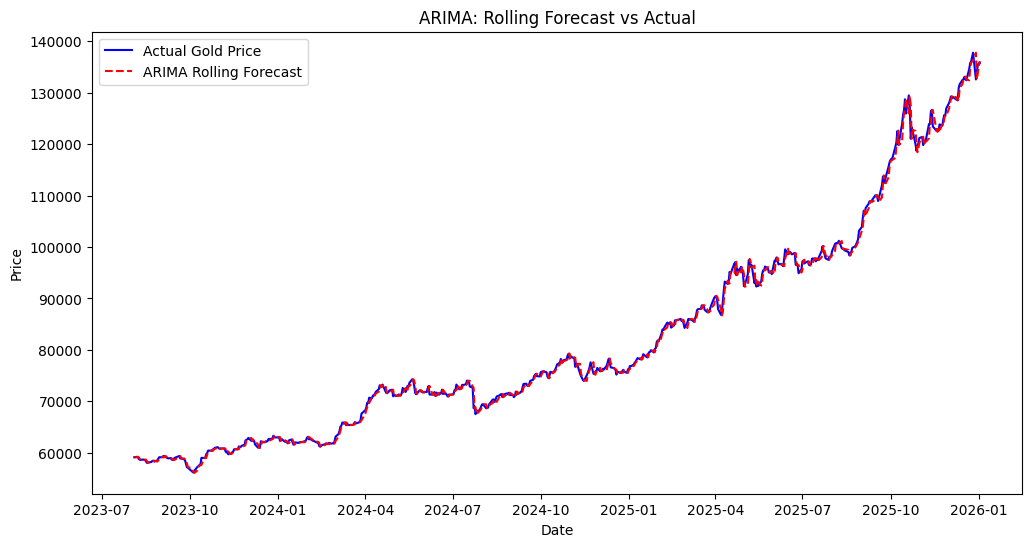

In [48]:
history = [x for x in train_arima]
predictions = []

print("Starting rolling forecast...")
for t in range(len(test_arima)):
    model = ARIMA(history, order=(5,1,0))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    
    obs = test_arima.iloc[t]
    history.append(obs)

plt.figure(figsize=(12,6))
plt.plot(test_arima.index, test_arima, label='Actual Gold Price', color='blue')
plt.plot(test_arima.index, predictions, label='ARIMA Rolling Forecast', color='red', linestyle='--')
plt.title('ARIMA: Rolling Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.savefig("Figures/ARIMA Rolling Forecast vs Actual.png")
plt.show()

#### Stochastic Analyze

In [49]:
window = 14

low_min = data['Low'].rolling(window=window).min()
high_max = data['High'].rolling(window=window).max()

data['%K'] = ((data['Price'] - low_min) / (high_max - low_min)) * 100
data['%D'] = data['%K'].rolling(3).mean()

data = data.dropna()

train_size = int(len(data) * 0.8)
train = data.iloc[:train_size]
test = data.iloc[train_size:].copy()

test['%K'] = data['%K'].iloc[train_size:].values


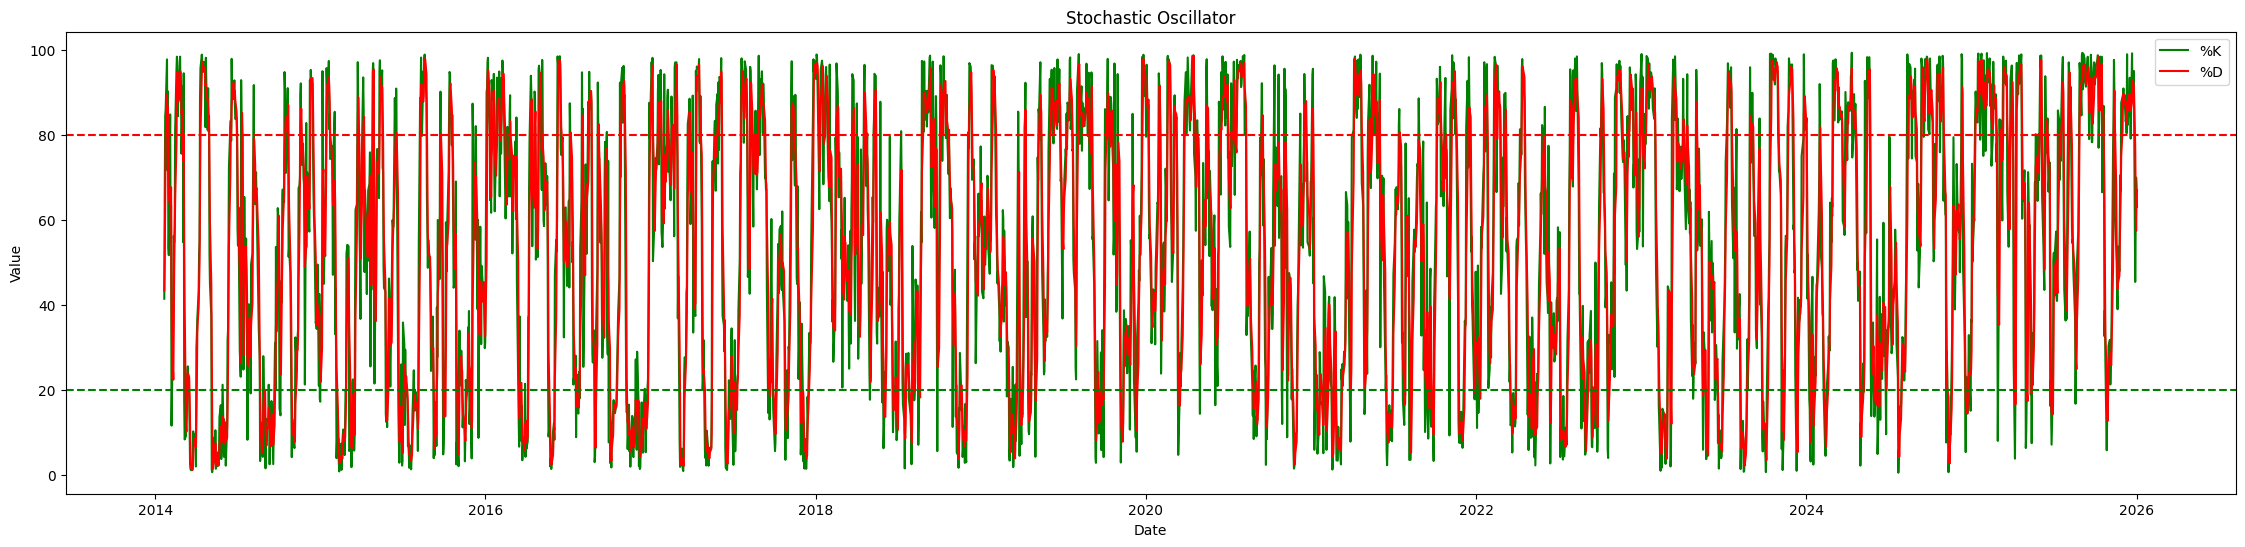

In [50]:
plt.figure(figsize=(28,6))
plt.plot(data['%K'], label='%K', color='green')
plt.plot(data['%D'], label='%D', color='red')
plt.axhline(80, color='red', linestyle='--')
plt.axhline(20, color='green', linestyle='--')
plt.legend()
plt.title('Stochastic Oscillator')
plt.xlabel('Date')
plt.ylabel('Value')
plt.savefig("Figures/Stochastic Oscillator.png")
plt.show()